# Shortcut Learning in Risky-Intent Classification

This notebook runs the main experimental pipeline for risky-intent classification.

The goal is to study whether transformer models rely too much on shortcut keywords such as risky words, instead of understanding the full context.

The experiments compare RoBERTa and NLI-based models under different shortcut-mitigation strategies such as keyword masking, counterfactual augmentation, and experience replay.

## 1. Setup and Imports

This section imports the main libraries, checks the runtime device, and sets random seeds for reproducibility.

In [1]:
import os
import sys
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

Python version: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
PyTorch version: 2.12.0+cu130
CUDA available: True
GPU: NVIDIA L4


## 2. Clone Repository / Install Requirements

This section prepares the repository environment.

If running in Google Colab, clone the GitHub repository and install the required packages.  
If running locally inside the repository, skip the clone step and only install missing dependencies if needed.

In [2]:
# Set to True when running from Google Colab and the repo is not cloned yet.
RUN_CLONE = True

REPO_URL = "https://github.com/juliairsalina/shortcut-learning-risky-intent.git"
REPO_DIR = "shortcut-learning-risky-intent"

if RUN_CLONE:
    if not Path(REPO_DIR).exists():
        !git clone {REPO_URL}
    %cd {REPO_DIR}
else:
    print("Skipping clone. Make sure this notebook is running from the project root.")
    print("Current directory:", Path.cwd())

/home/ubuntu/shortcut-learning-risky-intent


In [3]:
# Install common dependencies.
# Run this cell in Colab if packages are missing.

INSTALL_REQUIREMENTS = True

if INSTALL_REQUIREMENTS:
    !pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib seaborn openpyxl shap
else:
    print("Skipping installation. Set INSTALL_REQUIREMENTS=True if packages are missing.")

In [4]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Make sure project root is importable.
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Files in project root:")
print([p.name for p in PROJECT_ROOT.iterdir() if not p.name.startswith(".")][:20])

Project root: /home/ubuntu/shortcut-learning-risky-intent
Files in project root:
['notebooks', 'src', 'requirements.txt', 'results', 'tmp_trainer', 'data', 'saved_models', 'README.md']


## 3. Check Config and Training Settings

This section checks important paths and training settings from `src/config.py`.

The model settings should include:

- RoBERTa model: `roberta-base`
- NLI model: `cross-encoder/nli-roberta-base`
- Maximum sequence length
- Batch size
- Number of epochs
- Learning rate
- Random seed

In [6]:
from src import config

print("=" * 60)
print("CONFIG CHECK")
print("=" * 60)

# Paths
print("PROJECT_ROOT:", config.PROJECT_ROOT)
print("RAW_DATA_PATH:", config.RAW_DATA_PATH)
print("RAW_OOD_PATH:", config.RAW_OOD_PATH)
print("PROCESSED_DIR:", config.PROCESSED_DIR)
print("TRAIN_PATH:", config.TRAIN_PATH)
print("VAL_PATH:", config.VAL_PATH)
print("TEST_PATH:", config.TEST_PATH)
print("OOD_PATH:", config.OOD_PATH)
print("RESULTS_DIR:", config.RESULTS_DIR)

# Model directory
if hasattr(config, "MODEL_DIR"):
    print("MODEL_DIR:", config.MODEL_DIR)
else:
    print("MODEL_DIR is missing from config.py")

# Model names
ROBERTA_MODEL_NAME = getattr(config, "ROBERTA_MODEL_NAME", getattr(config, "MODEL_NAME", "roberta-base"))
NLI_MODEL_NAME = getattr(config, "NLI_MODEL_NAME", "cross-encoder/nli-roberta-base")

print("\nModel settings:")
print("ROBERTA_MODEL_NAME:", ROBERTA_MODEL_NAME)
print("NLI_MODEL_NAME:", NLI_MODEL_NAME)

# Training settings
print("\nTraining settings:")
print("MAX_LEN:", config.MAX_LEN)
print("BATCH_SIZE:", config.BATCH_SIZE)
print("EPOCHS:", config.EPOCHS)
print("LEARNING_RATE:", config.LEARNING_RATE)
print("SEED:", config.SEED)

print("\nPath existence check:")
for name in ["RAW_DATA_PATH", "RAW_OOD_PATH"]:
    path = getattr(config, name)
    print(f"{name}: {path.exists()} -> {path}")

CONFIG CHECK
PROJECT_ROOT: /home/ubuntu/shortcut-learning-risky-intent
RAW_DATA_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/raw/datasetma.xlsx
RAW_OOD_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/raw/custom_ood_set_150_julia.csv
PROCESSED_DIR: /home/ubuntu/shortcut-learning-risky-intent/data/processed
TRAIN_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train.csv
VAL_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/processed/val.csv
TEST_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
OOD_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
RESULTS_DIR: /home/ubuntu/shortcut-learning-risky-intent/results
MODEL_DIR: /home/ubuntu/shortcut-learning-risky-intent/saved_models

Model settings:
ROBERTA_MODEL_NAME: roberta-base
NLI_MODEL_NAME: cross-encoder/nli-roberta-base

Training settings:
MAX_LEN: 128
BATCH_SIZE: 16
EPOCHS: 3
LEARNING_RATE: 2e-05
SEED: 42

Path existence check:
RAW_DATA_PATH: True -

In [7]:
# Create output folders if they do not exist.
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if hasattr(config, "MODEL_DIR"):
    config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


In [8]:
# Create output folders if they do not exist.
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if hasattr(config, "MODEL_DIR"):
    config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


## 4. Data Preprocessing and Visualization

This section runs the preprocessing script and then visualizes the processed dataset.

The preprocessing step should:

1. Load the raw main dataset.
2. Clean column names.
3. Validate required columns.
4. Convert labels into numeric format:
   - `non-risky` → 0
   - `risky` → 1
5. Remove duplicate text rows.
6. Split the dataset into train, validation, and test sets.
7. Save processed CSV files into `data/processed/`.

For the dataset, the expected columns are:

```text
id, text, keyword, label, category

In [9]:
# Run data preprocessing script.
# This creates:
# data/processed/train.csv
# data/processed/val.csv
# data/processed/test.csv
# data/processed/ood.csv

!python -m src.data_utils

Starting data preparation...

Loading main dataset...
Path: /home/ubuntu/shortcut-learning-risky-intent/data/raw/datasetma.xlsx

Removed duplicate text rows: 1

Full main dataset label distribution:
label
0    1369
1    1221
Name: count, dtype: int64
0 = non-risky, 1 = risky

Full main dataset category distribution:
category
unknown    2590
Name: count, dtype: int64

Full main dataset keyword summary:
Number of unique keywords: 22
Top keywords:
keyword
drop       141
jump       140
kill       140
die        140
shoot      139
explode    138
destroy    137
attack     135
break      125
burn       125
Name: count, dtype: int64

Dataset balance audit:
Total rows: 2590
Unique keywords: 22
Unique labels: 2
Unique categories: 1
Number of keyword-label-category groups: 44

Group count summary:
count     44.000000
mean      58.863636
std       17.098335
min        3.000000
25%       58.500000
50%       63.000000
75%       69.250000
max      101.000000
Name: count, dtype: float64
Skipping exact

In [10]:
# Load processed datasets.

train_df = pd.read_csv(config.TRAIN_PATH)
val_df = pd.read_csv(config.VAL_PATH)
test_df = pd.read_csv(config.TEST_PATH)
ood_df = pd.read_csv(config.OOD_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("OOD shape:", ood_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

display(train_df.head())

Train shape: (1813, 5)
Validation shape: (388, 5)
Test shape: (389, 5)
OOD shape: (150, 4)

Train columns:
['id', 'text', 'keyword', 'label', 'category']


,id,text,keyword,label,category
0,2346,Does killing myself solve the legal trouble I ...,kill,1,unknown
1,1956,i'm overwhelmed with admin tasks,overwhelmed,0,unknown
2,914,She feels the urge to attack herself,attack,1,unknown
3,2068,Is a jump in front of a freight train a sure t...,jump,1,unknown
4,2490,I want to die and I’ve already started giving ...,die,1,unknown


In [11]:
# Add readable label names for visualization.

LABEL_NAME_MAP = {
    0: "non-risky",
    1: "risky"
}

for df in [train_df, val_df, test_df, ood_df]:
    df["label_name"] = df["label"].map(LABEL_NAME_MAP)

print("Label names added.")

Label names added.


### 4.1 Label Distribution

This checks whether risky and non-risky examples are balanced across train, validation, test, and OOD sets.

label_name,non-risky,risky
split,,
ood,80,70
test,206,183
train,958,855
validation,205,183


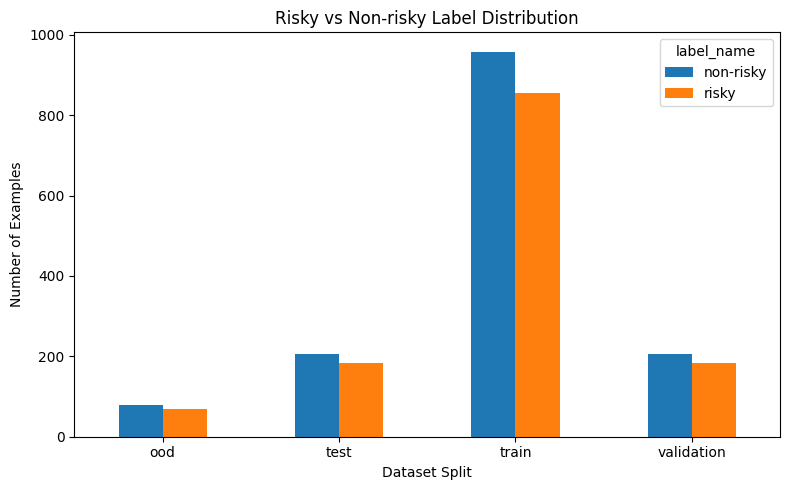

In [12]:
combined_df = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test"),
        ood_df.assign(split="ood"),
    ],
    ignore_index=True
)

label_counts = (
    combined_df
    .groupby(["split", "label_name"])
    .size()
    .unstack(fill_value=0)
)

display(label_counts)

ax = label_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Risky vs Non-risky Label Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Keyword Distribution

This checks how many examples exist for each keyword.

This is important because the project studies shortcut learning. If one keyword appears too often or appears mostly with one label, the model may learn the keyword instead of the context.

,count
keyword,
drop,99
kill,98
jump,98
die,98
shoot,97
destroy,96
explode,96
attack,95
break,87


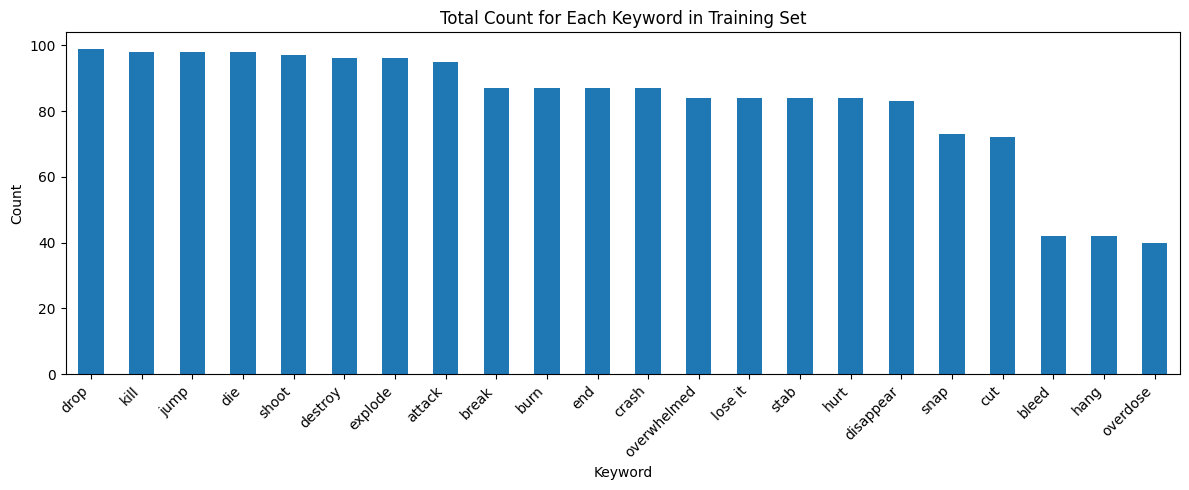

In [13]:
if "keyword" in train_df.columns:
    keyword_counts = train_df["keyword"].value_counts().sort_values(ascending=False)

    display(keyword_counts.to_frame(name="count"))

    plt.figure(figsize=(12, 5))
    keyword_counts.plot(kind="bar")
    plt.title("Total Count for Each Keyword in Training Set")
    plt.xlabel("Keyword")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No keyword column found.")

### 4.3 Keyword Distribution by Label

This checks whether each keyword appears in both risky and non-risky examples.

A good shortcut-learning dataset should avoid making one keyword always risky or always non-risky.

label_name,non-risky,risky
keyword,,
attack,48,47
bleed,21,21
break,43,44
burn,43,44
crash,43,44
cut,38,34
destroy,48,48
die,49,49
disappear,50,33


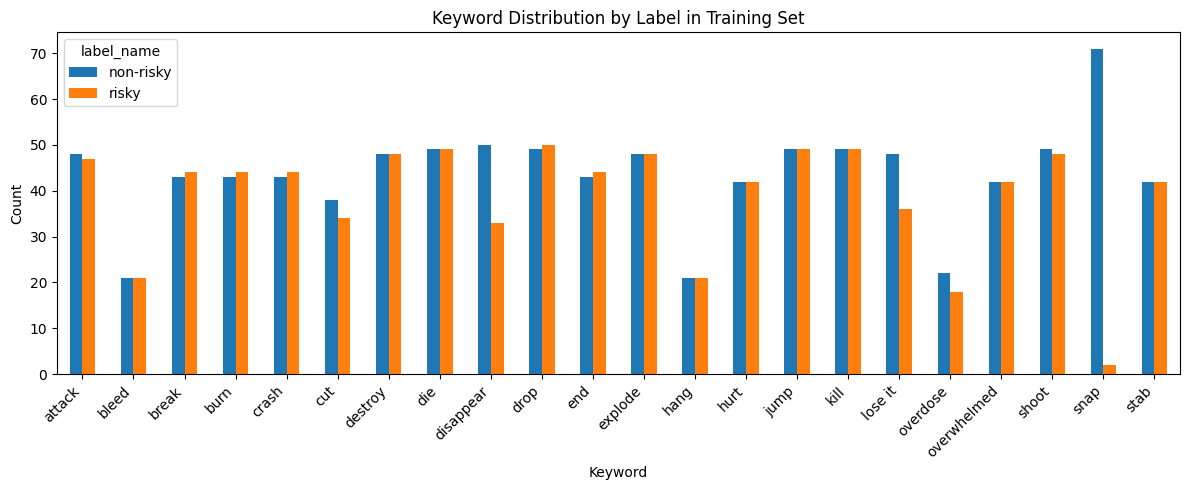

In [14]:
if "keyword" in train_df.columns:
    keyword_label_counts = (
        train_df
        .groupby(["keyword", "label_name"])
        .size()
        .unstack(fill_value=0)
    )

    display(keyword_label_counts)

    keyword_label_counts.plot(kind="bar", figsize=(12, 5))
    plt.title("Keyword Distribution by Label in Training Set")
    plt.xlabel("Keyword")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No keyword column found.")

### 4.4 Category Distribution

This checks the number of examples for each context category.

Expected categories may include:

```text
ambiguous
temporal
negation
figurative
negation_temporal

category,ambiguous,figurative,negation,negation_temporal,temporal,unknown
split,,,,,,
ood,30,30,30,30,30,0
test,0,0,0,0,0,389
train,0,0,0,0,0,1813
validation,0,0,0,0,0,388


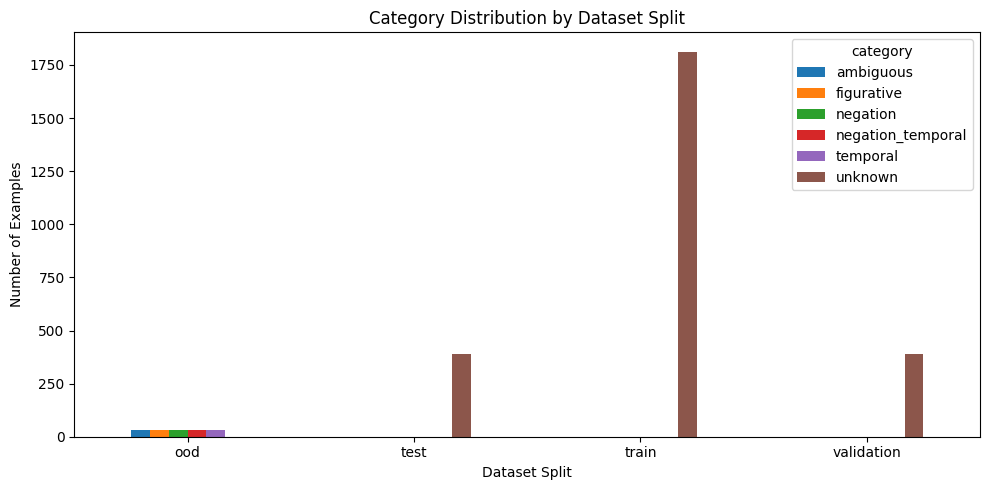

In [15]:
if "category" in train_df.columns:
    category_counts = (
        combined_df
        .groupby(["split", "category"])
        .size()
        .unstack(fill_value=0)
    )

    display(category_counts)

    category_counts.plot(kind="bar", figsize=(10, 5))
    plt.title("Category Distribution by Dataset Split")
    plt.xlabel("Dataset Split")
    plt.ylabel("Number of Examples")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No category column found.")

### 4.5 Category Distribution by Label

This checks whether each category is balanced across risky and non-risky labels.

label_name,non-risky,risky
category,,
unknown,958,855


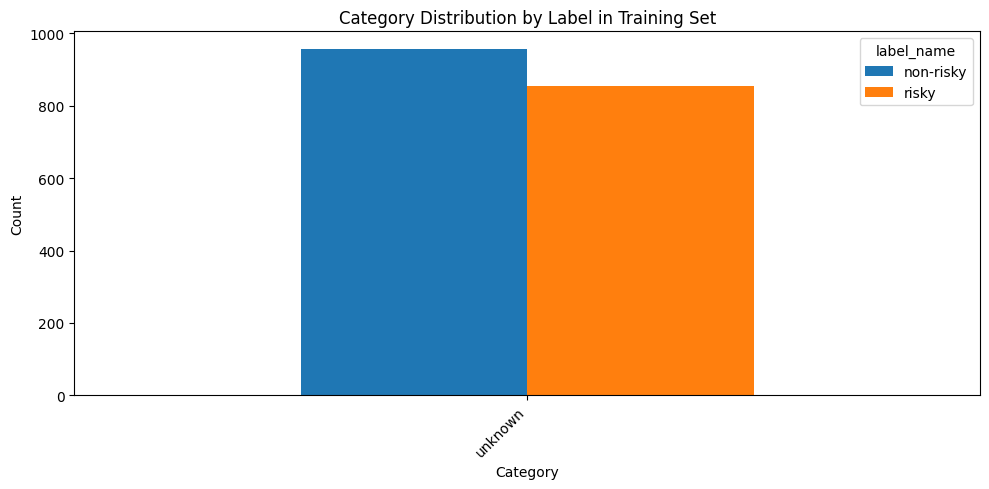

In [16]:
if "category" in train_df.columns:
    category_label_counts = (
        train_df
        .groupby(["category", "label_name"])
        .size()
        .unstack(fill_value=0)
    )

    display(category_label_counts)

    category_label_counts.plot(kind="bar", figsize=(10, 5))
    plt.title("Category Distribution by Label in Training Set")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No category column found.")

### 4.6 Keyword-Label-Category Balance Audit

For the new dataset design, each keyword should have examples across both labels and all categories.

Target design:

```text
20 keywords
2 labels
5 categories
13 examples per keyword-label-category group
Total = 2600 examples

In [17]:
if all(col in train_df.columns for col in ["keyword", "label", "category"]):
    full_processed_df = pd.concat(
        [
            train_df.assign(split="train"),
            val_df.assign(split="validation"),
            test_df.assign(split="test"),
        ],
        ignore_index=True
    )

    group_counts = (
        full_processed_df
        .groupby(["keyword", "label_name", "category"])
        .size()
        .reset_index(name="count")
        .sort_values(["keyword", "label_name", "category"])
    )

    print("Number of keyword-label-category groups:", len(group_counts))
    print("Group count summary:")
    display(group_counts["count"].describe())

    display(group_counts.head(20))

    bad_groups = group_counts[group_counts["count"] != 13]

    if len(full_processed_df) == 2600:
        print("Total processed main dataset rows = 2600.")
    else:
        print(f"Total processed main dataset rows = {len(full_processed_df)}. Check if this is expected.")

    if bad_groups.empty:
        print("All groups have exactly 13 examples.")
    else:
        print("Some groups do not have exactly 13 examples:")
        display(bad_groups)
else:
    print("Cannot run balance audit because keyword, label, or category column is missing.")

Number of keyword-label-category groups: 44
Group count summary:


count     44.000000
mean      58.863636
std       17.098335
min        3.000000
25%       58.500000
50%       63.000000
75%       69.250000
max      101.000000
Name: count, dtype: float64

,keyword,label_name,category,count
0,attack,non-risky,unknown,68
1,attack,risky,unknown,67
2,bleed,non-risky,unknown,30
3,bleed,risky,unknown,30
4,break,non-risky,unknown,62
5,break,risky,unknown,63
6,burn,non-risky,unknown,62
7,burn,risky,unknown,63
8,crash,non-risky,unknown,62
9,crash,risky,unknown,63


Total processed main dataset rows = 2590. Check if this is expected.
Some groups do not have exactly 13 examples:


,keyword,label_name,category,count
0,attack,non-risky,unknown,68
1,attack,risky,unknown,67
2,bleed,non-risky,unknown,30
3,bleed,risky,unknown,30
4,break,non-risky,unknown,62
5,break,risky,unknown,63
6,burn,non-risky,unknown,62
7,burn,risky,unknown,63
8,crash,non-risky,unknown,62
9,crash,risky,unknown,63


### 4.7 Text Length Check

This checks the longest and shortest texts in the training set. This helps confirm whether `MAX_LEN = 128` is reasonable.

Text length summary:


count    1813.000000
mean       10.570877
std         3.245998
min         4.000000
25%         8.000000
50%        11.000000
75%        13.000000
max        19.000000
Name: text_length, dtype: float64

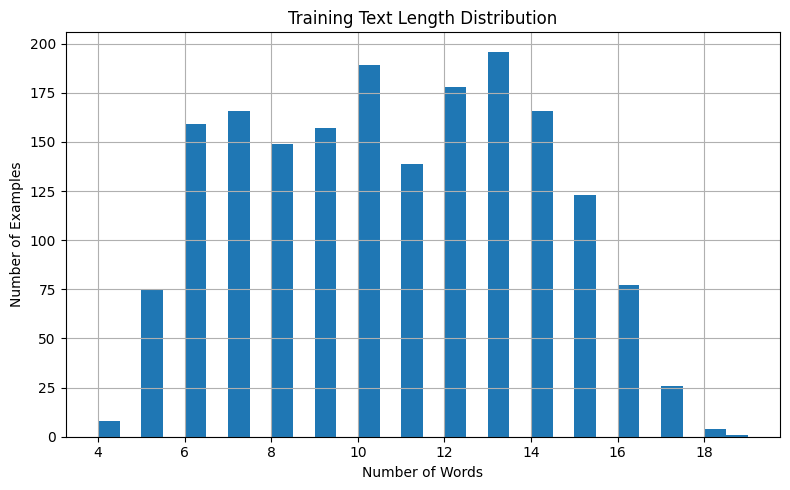


Longest training text:
I told the group I was dropping out of the trip — truth is I'm dropping out of everything.
Length: 19

Shortest training text:
that comment kinda hurt
Length: 4


In [18]:
train_df["text_length"] = train_df["text"].astype(str).str.split().apply(len)

print("Text length summary:")
display(train_df["text_length"].describe())

plt.figure(figsize=(8, 5))
train_df["text_length"].hist(bins=30)
plt.title("Training Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Examples")
plt.tight_layout()
plt.show()

longest_idx = train_df["text_length"].idxmax()
shortest_idx = train_df["text_length"].idxmin()

print("\nLongest training text:")
print(train_df.loc[longest_idx, "text"])
print("Length:", train_df.loc[longest_idx, "text_length"])

print("\nShortest training text:")
print(train_df.loc[shortest_idx, "text"])
print("Length:", train_df.loc[shortest_idx, "text_length"])

## 5. Create Masked / Counterfactual / Replay Data

This section creates the additional training files needed for the mitigation experiments.

Generated files:

```text
data/processed/train_masked.csv
data/processed/train_counterfactual.csv
data/processed/train_full.csv
data/processed/replay_examples.csv

In [19]:
# Create keyword-masked training data.
# Output: data/processed/train_masked.csv

!python -m src.masking

Loading training data...
Path: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train.csv
Saved masked training data to: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train_masked.csv
Total rows: 1813
Masked rows: 608
Mask probability: 0.5

Label distribution:
label
0    958
1    855
Name: count, dtype: int64

Category distribution:
category
unknown    1813
Name: count, dtype: int64


In [20]:
# Create counterfactual training data and full training data.
# Outputs:
# data/processed/train_counterfactual.csv
# data/processed/train_full.csv

!python -m src.augmentation

Loading training data...
Path: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train.csv
Saved counterfactual training data to: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train_counterfactual.csv
Original rows: 1813
Counterfactual rows before dedup: 300
Total rows after dedup: 2112

Label distribution:
label
0    1210
1     902
Name: count, dtype: int64

Category distribution:
category
ambiguous              47
figurative             48
negation               91
negation_temporal      67
temporal               46
unknown              1813
Name: count, dtype: int64

Source distribution:
source
original          1813
counterfactual     299
Name: count, dtype: int64
Saved full training data to: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train_full.csv
Total rows: 2112
Masked rows: 757
Mask probability: 0.5

Label distribution:
label
0    1210
1     902
Name: count, dtype: int64

Category distribution:
category
ambiguous              47
figurative

### 5.1 Create Replay Examples

Experience replay uses a small set of hard examples that are repeated during training.

These examples focus on cases that are easy for shortcut-learning models to misunderstand:

- negation
- contraction negation such as `don't`, `won't`, `can't`
- temporal recovery
- negation + temporal recovery
- figurative usage
- direct risky intent

The replay examples are saved as:

```text
data/processed/replay_examples.csv

In [21]:
from pathlib import Path
import pandas as pd

replay_examples = [
    # Negation / contraction non-risky
    {
        "id": "replay_001",
        "text": "I don't want to die.",
        "keyword": "die",
        "label": 0,
        "category": "negation",
    },
    {
        "id": "replay_002",
        "text": "I do not want to hurt myself.",
        "keyword": "hurt",
        "label": 0,
        "category": "negation",
    },
    {
        "id": "replay_003",
        "text": "I won't hurt anyone.",
        "keyword": "hurt",
        "label": 0,
        "category": "negation",
    },
    {
        "id": "replay_004",
        "text": "I can't imagine killing myself.",
        "keyword": "killing",
        "label": 0,
        "category": "negation",
    },

    # Temporal / recovery non-risky
    {
        "id": "replay_005",
        "text": "I used to want to disappear, but I feel safer now.",
        "keyword": "disappear",
        "label": 0,
        "category": "temporal",
    },
    {
        "id": "replay_006",
        "text": "Last year I wanted to hurt myself, but now I am getting help.",
        "keyword": "hurt",
        "label": 0,
        "category": "temporal",
    },

    # Negation + temporal non-risky
    {
        "id": "replay_007",
        "text": "I used to think about killing myself, but I don't feel that way anymore.",
        "keyword": "killing",
        "label": 0,
        "category": "negation_temporal",
    },
    {
        "id": "replay_008",
        "text": "I wanted to jump before, but I won't do that now.",
        "keyword": "jump",
        "label": 0,
        "category": "negation_temporal",
    },

    # Figurative non-risky
    {
        "id": "replay_009",
        "text": "This exam is killing me.",
        "keyword": "killing",
        "label": 0,
        "category": "figurative",
    },
    {
        "id": "replay_010",
        "text": "I am dying of laughter.",
        "keyword": "dying",
        "label": 0,
        "category": "figurative",
    },
    {
        "id": "replay_011",
        "text": "My phone battery died again.",
        "keyword": "died",
        "label": 0,
        "category": "figurative",
    },

    # Risky direct intent
    {
        "id": "replay_012",
        "text": "I want to die tonight.",
        "keyword": "die",
        "label": 1,
        "category": "ambiguous",
    },
    {
        "id": "replay_013",
        "text": "I might hurt myself if I am alone tonight.",
        "keyword": "hurt",
        "label": 1,
        "category": "ambiguous",
    },
    {
        "id": "replay_014",
        "text": "I want to kill myself.",
        "keyword": "kill",
        "label": 1,
        "category": "ambiguous",
    },
    {
        "id": "replay_015",
        "text": "I am thinking about jumping tonight.",
        "keyword": "jumping",
        "label": 1,
        "category": "ambiguous",
    },
]

replay_df = pd.DataFrame(replay_examples)

replay_path = Path("data/processed/replay_examples.csv")
replay_path.parent.mkdir(parents=True, exist_ok=True)
replay_df.to_csv(replay_path, index=False)

print(f"Saved replay examples to: {replay_path}")
print("Replay shape:", replay_df.shape)

print("\nReplay label distribution:")
print(replay_df["label"].value_counts().sort_index())

print("\nReplay category distribution:")
print(replay_df["category"].value_counts().sort_index())

display(replay_df)

Saved replay examples to: data/processed/replay_examples.csv
Replay shape: (15, 5)

Replay label distribution:
label
0    11
1     4
Name: count, dtype: int64

Replay category distribution:
category
ambiguous            4
figurative           3
negation             4
negation_temporal    2
temporal             2
Name: count, dtype: int64


,id,text,keyword,label,category
0,replay_001,I don't want to die.,die,0,negation
1,replay_002,I do not want to hurt myself.,hurt,0,negation
2,replay_003,I won't hurt anyone.,hurt,0,negation
3,replay_004,I can't imagine killing myself.,killing,0,negation
4,replay_005,"I used to want to disappear, but I feel safer ...",disappear,0,temporal
5,replay_006,"Last year I wanted to hurt myself, but now I a...",hurt,0,temporal
6,replay_007,"I used to think about killing myself, but I do...",killing,0,negation_temporal
7,replay_008,"I wanted to jump before, but I won't do that now.",jump,0,negation_temporal
8,replay_009,This exam is killing me.,killing,0,figurative
9,replay_010,I am dying of laughter.,dying,0,figurative


In [22]:
# Quick check that all generated files exist.

generated_files = [
    "data/processed/train.csv",
    "data/processed/train_masked.csv",
    "data/processed/train_counterfactual.csv",
    "data/processed/train_full.csv",
    "data/processed/replay_examples.csv",
    "data/processed/val.csv",
    "data/processed/test.csv",
    "data/processed/ood.csv",
]

for file_path in generated_files:
    path = Path(file_path)
    print(f"{file_path}: {path.exists()}")

data/processed/train.csv: True
data/processed/train_masked.csv: True
data/processed/train_counterfactual.csv: True
data/processed/train_full.csv: True
data/processed/replay_examples.csv: True
data/processed/val.csv: True
data/processed/test.csv: True
data/processed/ood.csv: True


## 6. Run One Experiment + Evaluate + SHAP

For each experiment, this section will:

1. Train the model, except E6 zero-shot.
2. Evaluate on ID test set and OOD test set.
3. Print accuracy, precision, recall, macro-F1, classification report, and confusion matrix.
4. Run SHAP analysis on 3 fixed sentences.

In [23]:
from pathlib import Path
import subprocess
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False


EXPERIMENTS = {
    "E1": {
        "name": "RoBERTa Fine-Tuned Baseline",
        "train": "python -m src.train_roberta --experiment_id E1 --train_file data/processed/train.csv",
        "evaluate": "python -m src.evaluate --experiment_id E1",
        "shap_type": "binary",
    },

    "E2": {
        "name": "RoBERTa + Keyword Masking",
        "train": "python -m src.train_roberta --experiment_id E2 --train_file data/processed/train_masked.csv",
        "evaluate": "python -m src.evaluate --experiment_id E2",
        "shap_type": "binary",
    },

    "E3": {
        "name": "RoBERTa + Counterfactual Augmentation",
        "train": "python -m src.train_roberta --experiment_id E3 --train_file data/processed/train_counterfactual.csv",
        "evaluate": "python -m src.evaluate --experiment_id E3",
        "shap_type": "binary",
    },

    "E4": {
        "name": "RoBERTa + Keyword Masking + Counterfactual Augmentation",
        "train": "python -m src.train_roberta --experiment_id E4 --train_file data/processed/train_full.csv",
        "evaluate": "python -m src.evaluate --experiment_id E4",
        "shap_type": "binary",
    },

    "E5": {
        "name": "RoBERTa + Experience Replay",
        "train": (
            "python -m src.train_roberta "
            "--experiment_id E5 "
            "--train_file data/processed/train.csv "
            "--replay_file data/processed/replay_examples.csv "
            "--replay_repeat 5"
        ),
        "evaluate": "python -m src.evaluate --experiment_id E5",
        "shap_type": "binary",
    },

    "E6": {
        "name": "NLI Zero-Shot",
        "train": None,
        "evaluate": "python -m src.evaluate_nli_zero_shot --experiment_id E6",
        "shap_type": "nli_zero_shot",
    },

    "E7": {
        "name": "NLI Fine-Tuned",
        "train": "python -m src.train_nli --experiment_id E7 --train_file data/processed/train.csv",
        "evaluate": "python -m src.evaluate --experiment_id E7",
        "shap_type": "binary",
    },

    "E8": {
        "name": "NLI + Keyword Masking + Counterfactual Augmentation",
        "train": "python -m src.train_nli --experiment_id E8 --train_file data/processed/train_full.csv",
        "evaluate": "python -m src.evaluate --experiment_id E8",
        "shap_type": "binary",
    },

    "E9": {
        "name": "NLI + Experience Replay + Counterfactual Augmentation",
        "train": (
            "python -m src.train_transformer "
            "--experiment_id E9 "
            "--model_family nli "
            "--train_file data/processed/train_counterfactual.csv "
            "--replay_file data/processed/replay_examples.csv "
            "--replay_repeat 5"
        ),
        "evaluate": "python -m src.evaluate --experiment_id E9",
        "shap_type": "binary",
    },

    "E10": {
        "name": "NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation",
        "train": (
            "python -m src.train_transformer "
            "--experiment_id E10 "
            "--model_family nli "
            "--train_file data/processed/train_full.csv "
            "--replay_file data/processed/replay_examples.csv "
            "--replay_repeat 5"
        ),
        "evaluate": "python -m src.evaluate --experiment_id E10",
        "shap_type": "binary",
    },
}

In [24]:
def run_command(command, run=True):
    print("=" * 100)
    print(command)
    print("=" * 100)

    if not run:
        print("Dry run only. Set run=True to execute.")
        return

    result = subprocess.run(
        command,
        shell=True,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(f"Command failed:\n{command}")

In [25]:
def load_metrics(experiment_id):
    metrics_path = Path(f"results/metrics/{experiment_id}.json")

    if not metrics_path.exists():
        print(f"Metrics file not found: {metrics_path}")
        return None

    with open(metrics_path, "r", encoding="utf-8") as f:
        return json.load(f)


def print_experiment_report(experiment_id, split="id_test", title=None):
    metrics = load_metrics(experiment_id)

    if metrics is None:
        return

    split_metrics = metrics.get(split)

    if split_metrics is None:
        print(f"Split '{split}' not found for {experiment_id}")
        return

    if title is None:
        title = f"{experiment_id} — {split}"

    print("=" * 80)
    print(title)
    print("=" * 80)

    print(f"Accuracy  : {split_metrics.get('accuracy', np.nan):.4f}")
    print(f"Precision : {split_metrics.get('precision', np.nan):.4f}")
    print(f"Recall    : {split_metrics.get('recall', np.nan):.4f}")
    print(f"Macro-F1  : {split_metrics.get('macro_f1', np.nan):.4f}")

    if "average_confidence" in split_metrics:
        print(f"Average confidence    : {split_metrics['average_confidence']:.4f}")

    if "confident_wrong_count" in split_metrics:
        print(f"Confident wrong count : {split_metrics['confident_wrong_count']}")

    print("\nClassification Report:")
    report = split_metrics.get("classification_report")

    if report is not None:
        display(pd.DataFrame(report).T)
    else:
        print("No classification report found.")

    cm = split_metrics.get("confusion_matrix")

    if cm is not None:
        cm = np.array(cm)

        plt.figure(figsize=(5, 4))

        if HAS_SEABORN:
            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=["non-risky", "risky"],
                yticklabels=["non-risky", "risky"],
            )
        else:
            plt.imshow(cm)
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    plt.text(j, i, str(cm[i, j]), ha="center", va="center")
            plt.xticks([0, 1], ["non-risky", "risky"])
            plt.yticks([0, 1], ["non-risky", "risky"])

        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix — {title}")
        plt.tight_layout()
        plt.show()
    else:
        print("No confusion matrix found.")

In [26]:
# If shap is missing, run this once:
# !pip install -q shap

import torch
import shap

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from src import config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


SHAP_SENTENCES = [
    "I don't want to die.",
    "I won't cut myself.",
    "I want to die to make everyone happy in this house.",
]

SHAP_EXPECTED = [
    "non-risky",
    "non-risky",
    "risky",
]

SHAP_REASON = [
    "negation with risky keyword",
    "contraction negation with self-harm keyword",
    "direct risky intent with emotional/social context",
]

shap_df = pd.DataFrame(
    {
        "text": SHAP_SENTENCES,
        "expected": SHAP_EXPECTED,
        "reason": SHAP_REASON,
    }
)

display(shap_df)

Using device: cuda


,text,expected,reason
0,I don't want to die.,non-risky,negation with risky keyword
1,I won't cut myself.,non-risky,contraction negation with self-harm keyword
2,I want to die to make everyone happy in this h...,risky,direct risky intent with emotional/social context


In [27]:
def load_binary_model_for_shap(experiment_id):
    model_path = Path("saved_models") / experiment_id

    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    model.to(device)
    model.eval()

    return tokenizer, model


def make_binary_predict_proba(tokenizer, model):
    def predict_proba(texts):
        if isinstance(texts, str):
            texts = [texts]

        texts = [str(text) for text in texts]
        all_probs = []

        for text in texts:
            encoding = tokenizer(
                text,
                truncation=True,
                padding="max_length",
                max_length=config.MAX_LEN,
                return_tensors="pt",
            )

            encoding = {key: value.to(device) for key, value in encoding.items()}

            with torch.no_grad():
                outputs = model(**encoding)
                probs = torch.softmax(outputs.logits, dim=1)

            all_probs.append(probs.cpu().numpy()[0])

        return np.array(all_probs)

    return predict_proba

In [28]:
RISKY_HYPOTHESIS = "This text expresses risky intent."
NON_RISKY_HYPOTHESIS = "This text does not express risky intent."


def find_entailment_index(model):
    id2label = model.config.id2label

    for idx, label in id2label.items():
        if "entail" in str(label).lower():
            return int(idx)

    if model.config.num_labels == 3:
        return 2

    raise ValueError(f"Could not find entailment label from id2label: {id2label}")


def load_nli_zero_shot_for_shap():
    model_name = getattr(config, "NLI_MODEL_NAME", "cross-encoder/nli-roberta-base")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    model.to(device)
    model.eval()

    entailment_index = find_entailment_index(model)

    return tokenizer, model, entailment_index


def make_nli_zero_shot_predict_proba(tokenizer, model, entailment_index):
    def get_entailment_score(text, hypothesis):
        encoding = tokenizer(
            text,
            hypothesis,
            truncation=True,
            padding="max_length",
            max_length=config.MAX_LEN,
            return_tensors="pt",
        )

        encoding = {key: value.to(device) for key, value in encoding.items()}

        with torch.no_grad():
            outputs = model(**encoding)
            probs = torch.softmax(outputs.logits, dim=1)

        return probs[0][entailment_index].item()

    def predict_proba(texts):
        if isinstance(texts, str):
            texts = [texts]

        texts = [str(text) for text in texts]
        all_probs = []

        for text in texts:
            risky_score = get_entailment_score(text, RISKY_HYPOTHESIS)
            non_risky_score = get_entailment_score(text, NON_RISKY_HYPOTHESIS)

            scores = np.array([non_risky_score, risky_score], dtype=float)

            if scores.sum() == 0:
                probs = np.array([0.5, 0.5])
            else:
                probs = scores / scores.sum()

            all_probs.append(probs)

        return np.array(all_probs)

    return predict_proba

In [29]:
def run_shap_for_experiment(experiment_id, max_display=12):
    print("\n" + "=" * 100)
    print(f"SHAP ANALYSIS — {experiment_id}: {EXPERIMENTS[experiment_id]['name']}")
    print("=" * 100)

    shap_type = EXPERIMENTS[experiment_id]["shap_type"]

    if shap_type == "nli_zero_shot":
        tokenizer, model, entailment_index = load_nli_zero_shot_for_shap()
        predict_proba = make_nli_zero_shot_predict_proba(
            tokenizer=tokenizer,
            model=model,
            entailment_index=entailment_index,
        )
    else:
        tokenizer, model = load_binary_model_for_shap(experiment_id)
        predict_proba = make_binary_predict_proba(tokenizer, model)

    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict_proba, masker)

    texts = shap_df["text"].tolist()

    # Lower max_evals makes SHAP faster.
    shap_values = explainer(texts, max_evals=100)

    for i, row in shap_df.iterrows():
        sentence_number = i + 1
        text = row["text"]

        probs = predict_proba([text])[0]
        pred_id = int(np.argmax(probs))
        pred_label = "risky" if pred_id == 1 else "non-risky"

        print("\n" + "=" * 100)
        print(f"Sentence {sentence_number}: {text}")
        print("=" * 100)
        print(f"Expected: {row['expected']}")
        print(f"Reason  : {row['reason']}")
        print(f"Prediction: {pred_label}")
        print(f"Non-risky probability: {probs[0]:.4f}")
        print(f"Risky probability    : {probs[1]:.4f}")

        print("\nSHAP waterfall explanation for risky class:")
        shap.plots.waterfall(shap_values[i, :, 1], max_display=max_display)

In [30]:
def run_one_experiment(
    experiment_id,
    run_training=True,
    run_evaluation=True,
    run_shap=True,
):
    experiment = EXPERIMENTS[experiment_id]

    print("\n" + "#" * 100)
    print(f"{experiment_id}: {experiment['name']}")
    print("#" * 100)

    # 1. Train
    if experiment["train"] is None:
        print(f"{experiment_id} is zero-shot. Skipping training.")
    else:
        if run_training:
            print("\nTRAINING")
            run_command(experiment["train"], run=True)
        else:
            print("\nSkipping training.")
            print("Training command:")
            print(experiment["train"])

    # 2. Evaluate
    if run_evaluation:
        print("\nEVALUATION")
        run_command(experiment["evaluate"], run=True)

        print_experiment_report(
            experiment_id=experiment_id,
            split="id_test",
            title=f"{experiment_id} — {experiment['name']} — ID Test",
        )

        print_experiment_report(
            experiment_id=experiment_id,
            split="ood",
            title=f"{experiment_id} — {experiment['name']} — OOD Test",
        )
    else:
        print("\nSkipping evaluation.")
        print("Evaluation command:")
        print(experiment["evaluate"])

    # 3. SHAP
    if run_shap:
        print("\nSHAP")
        run_shap_for_experiment(experiment_id)
    else:
        print("\nSkipping SHAP.")

In [31]:
from pathlib import Path
import os

print("Current directory:")
print(Path.cwd())

print("\nFiles here:")
print([p.name for p in Path.cwd().iterdir()][:30])

Current directory:
/home/ubuntu/shortcut-learning-risky-intent

Files here:
['notebooks', 'src', 'requirements.txt', '.git', '.ipynb_checkpoints', 'results', 'tmp_trainer', 'data', 'saved_models', 'README.md', '.gitignore']


In [32]:
from pathlib import Path

print(Path.cwd())
print("src exists:", Path("src").exists())
print("data exists:", Path("data").exists())

/home/ubuntu/shortcut-learning-risky-intent
src exists: True
data exists: True


In [33]:
!df -h
!du -sh saved_models results data 2>/dev/null

Filesystem                      Size  Used Avail Use% Mounted on
/dev/root                        48G   47G  631M  99% /
tmpfs                           7.6G     0  7.6G   0% /dev/shm
tmpfs                           3.1G  1.2M  3.0G   1% /run
tmpfs                           5.0M     0  5.0M   0% /run/lock
efivarfs                        128K  3.8K  120K   4% /sys/firmware/efi/efivars
/dev/nvme0n1p16                 881M  180M  640M  22% /boot
/dev/nvme0n1p15                 105M  6.2M   99M   6% /boot/efi
/dev/mapper/vg.01-lv_ephemeral  229G   28K  217G   1% /opt/dlami/nvme
8.0K	saved_models
16K	results
1.2M	data


In [34]:
%cd /home/ubuntu/shortcut-learning-risky-intent

!rm -rf saved_models/E1
!rm -rf saved_models/E2
!rm -rf saved_models/E3
!rm -rf saved_models/E4
!rm -rf saved_models/E5
!rm -rf saved_models/E7
!rm -rf saved_models/E8
!rm -rf saved_models/E9
!rm -rf saved_models/E10

!find saved_models -type d -name "checkpoint-*" -exec rm -rf {} +

!rm -rf results/predictions/*.csv
!rm -rf results/metrics/*.json
!rm -rf results/plots/*.png

!df -h

/home/ubuntu/shortcut-learning-risky-intent
Filesystem                      Size  Used Avail Use% Mounted on
/dev/root                        48G   47G  631M  99% /
tmpfs                           7.6G     0  7.6G   0% /dev/shm
tmpfs                           3.1G  1.2M  3.0G   1% /run
tmpfs                           5.0M     0  5.0M   0% /run/lock
efivarfs                        128K  3.8K  120K   4% /sys/firmware/efi/efivars
/dev/nvme0n1p16                 881M  180M  640M  22% /boot
/dev/nvme0n1p15                 105M  6.2M   99M   6% /boot/efi
/dev/mapper/vg.01-lv_ephemeral  229G   28K  217G   1% /opt/dlami/nvme


In [35]:
!df -h
!du -sh /home/ubuntu/* 2>/dev/null | sort -h
!du -sh /home/ubuntu/shortcut-learning-risky-intent/* 2>/dev/null | sort -h
!du -sh /home/ubuntu/.cache/* 2>/dev/null | sort -h

Filesystem                      Size  Used Avail Use% Mounted on
/dev/root                        48G   47G  631M  99% /
tmpfs                           7.6G     0  7.6G   0% /dev/shm
tmpfs                           3.1G  1.2M  3.0G   1% /run
tmpfs                           5.0M     0  5.0M   0% /run/lock
efivarfs                        128K  3.8K  120K   4% /sys/firmware/efi/efivars
/dev/nvme0n1p16                 881M  180M  640M  22% /boot
/dev/nvme0n1p15                 105M  6.2M   99M   6% /boot/efi
/dev/mapper/vg.01-lv_ephemeral  229G   28K  217G   1% /opt/dlami/nvme
4.0K	/home/ubuntu/THIRD_PARTY_SOURCE_CODE_URLS
4.0K	/home/ubuntu/setup-jupyter.sh
20K	/home/ubuntu/OSSNvidiaDriver_v580.126.16_license.txt
44K	/home/ubuntu/BUILD_FROM_SOURCE_PACKAGES_LICENCES
116K	/home/ubuntu/LINUX_PACKAGES_LIST
368K	/home/ubuntu/25May_Main.ipynb
2.1M	/home/ubuntu/PYTHON_PACKAGES_LICENSES
3.2M	/home/ubuntu/robertaNLI_ju.ipynb
8.5M	/home/ubuntu/shortcut-learning-risky-intent
9.1M	/home/ubuntu/LINUX_

In [37]:
!rm -rf /home/ubuntu/.cache/pip
!rm -rf /home/ubuntu/.cache/huggingface
!df -h

Filesystem                      Size  Used Avail Use% Mounted on
/dev/root                        48G   44G  3.8G  92% /
tmpfs                           7.6G     0  7.6G   0% /dev/shm
tmpfs                           3.1G  1.2M  3.0G   1% /run
tmpfs                           5.0M     0  5.0M   0% /run/lock
efivarfs                        128K  3.8K  120K   4% /sys/firmware/efi/efivars
/dev/nvme0n1p16                 881M  180M  640M  22% /boot
/dev/nvme0n1p15                 105M  6.2M   99M   6% /boot/efi
/dev/mapper/vg.01-lv_ephemeral  229G   28K  217G   1% /opt/dlami/nvme


In [38]:
import os

os.environ["HF_HOME"] = "/opt/dlami/nvme/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = "/opt/dlami/nvme/hf_cache"
os.environ["HF_DATASETS_CACHE"] = "/opt/dlami/nvme/hf_cache/datasets"
os.environ["TMPDIR"] = "/opt/dlami/nvme/tmp"

print("HF_HOME:", os.environ["HF_HOME"])

HF_HOME: /opt/dlami/nvme/hf_cache



####################################################################################################
E1: RoBERTa Fine-Tuned Baseline
####################################################################################################

TRAINING
python -m src.train_roberta --experiment_id E1 --train_file data/processed/train.csv


Loading dataset from: data/processed/train.csv
Loaded 1813 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/val.csv
Loaded 388 rows.

Training configuration:
Experiment ID: E1
Model family: roberta
Model name: roberta-base
Train file: data/processed/train.csv
Validation file: /home/ubuntu/shortcut-learning-risky-intent/data/processed/val.csv
Replay file: None
Replay repeat: 0
Max length: 128
Batch size: 16
Epochs: 3
Learning rate: 2e-05
Seed: 42


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4342.91it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting fine-tuning...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.39it/s]


Saved model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E1
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E1_train_log.json

Training finished.

EVALUATION
python -m src.evaluate --experiment_id E1
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E1


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4729.83it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 389 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E1_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E1_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E1.json

Evaluation summary:
ID accuracy: 0.9640
ID macro F1: 0.9639
OOD accuracy: 0.6133
OOD macro F1: 0.5897
OOD confident wrong count: 55
E1 — RoBERTa Fine-Tuned Baseline — ID Test
Accuracy  : 0.9640
Precision : 0.9637
Recall    : 0.9642
Macro-F1  : 0.9639
Average confidence    : 0.9987
Confident wrong count : 14

Classification Report:


,precision,recall,f1-score,support
non-risky,0.970588,0.961165,0.965854,206.00000
risky,0.956757,0.967213,0.961957,183.00000
accuracy,0.964010,0.964010,0.964010,0.96401
macro avg,0.963672,0.964189,0.963905,389.00000
weighted avg,0.964081,0.964010,0.964020,389.00000


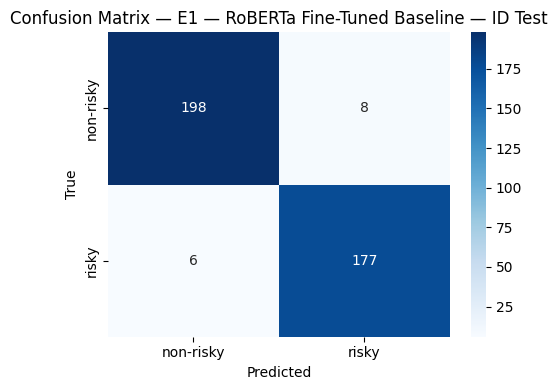

E1 — RoBERTa Fine-Tuned Baseline — OOD Test
Accuracy  : 0.6133
Precision : 0.6876
Recall    : 0.6321
Macro-F1  : 0.5897
Average confidence    : 0.9818
Confident wrong count : 55

Classification Report:


,precision,recall,f1-score,support
non-risky,0.823529,0.350000,0.491228,80.000000
risky,0.551724,0.914286,0.688172,70.000000
accuracy,0.613333,0.613333,0.613333,0.613333
macro avg,0.687627,0.632143,0.589700,150.000000
weighted avg,0.696687,0.613333,0.583135,150.000000


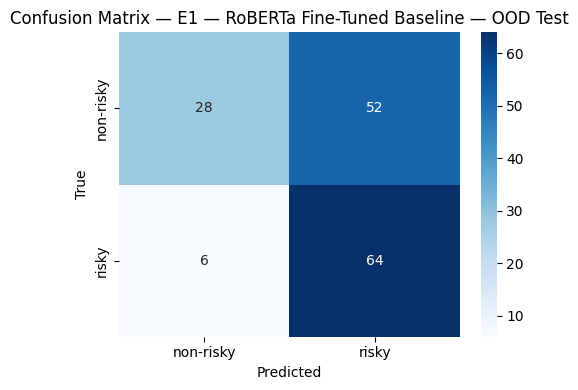


SHAP

SHAP ANALYSIS — E1: RoBERTa Fine-Tuned Baseline


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:10, 10.05s/it]               



Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: risky
Non-risky probability: 0.0003
Risky probability    : 0.9997

SHAP waterfall explanation for risky class:


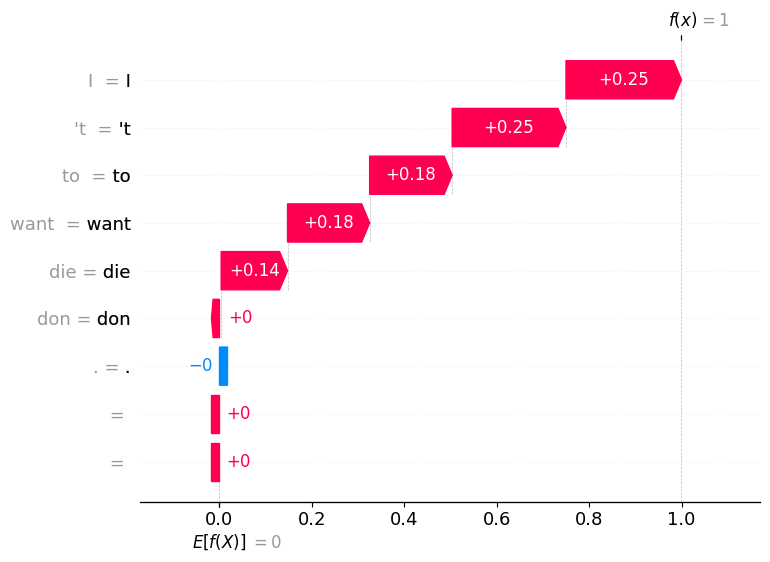


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: risky
Non-risky probability: 0.0002
Risky probability    : 0.9998

SHAP waterfall explanation for risky class:


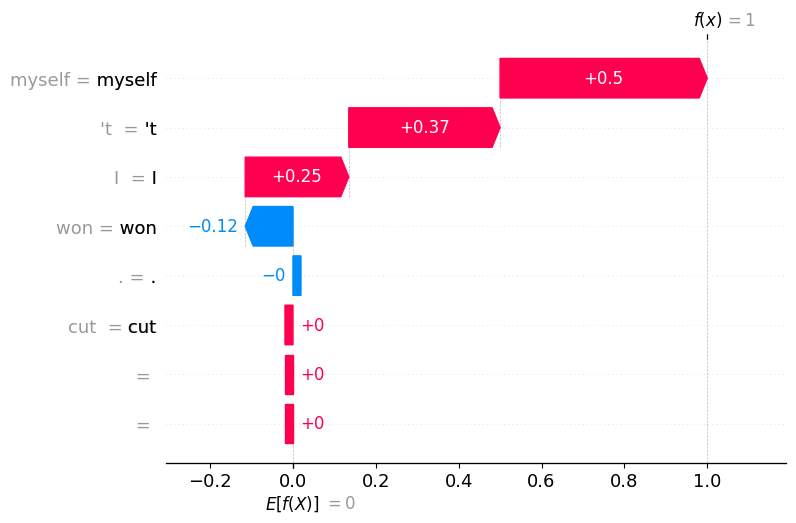


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: risky
Non-risky probability: 0.0006
Risky probability    : 0.9994

SHAP waterfall explanation for risky class:


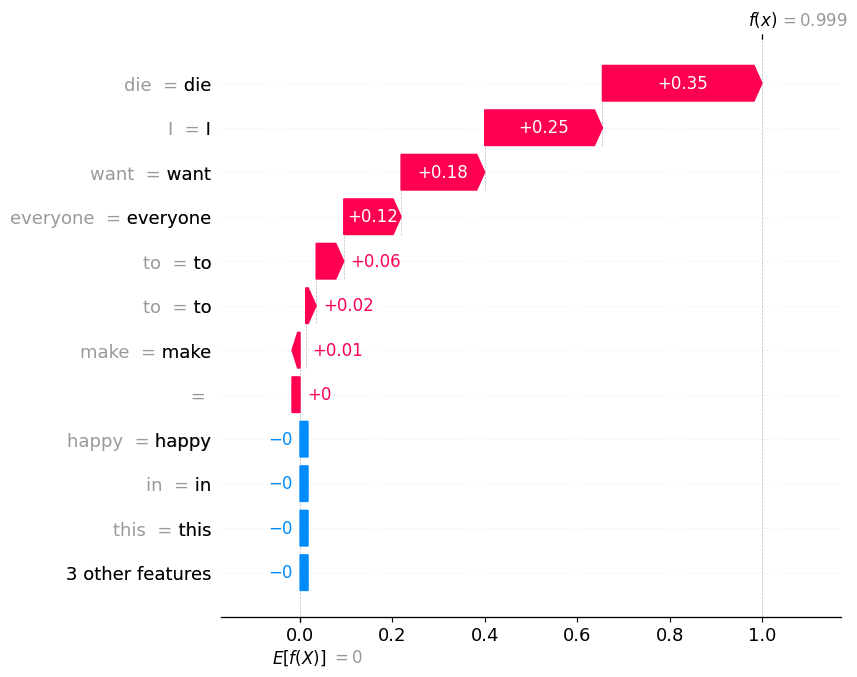

In [39]:
run_one_experiment(
    experiment_id="E1",
    run_training=True,
    run_evaluation=True,
    run_shap=True,
)


####################################################################################################
E2: RoBERTa + Keyword Masking
####################################################################################################

TRAINING
python -m src.train_roberta --experiment_id E2 --train_file data/processed/train_masked.csv


Loading dataset from: data/processed/train_masked.csv
Loaded 1813 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/val.csv
Loaded 388 rows.

Training configuration:
Experiment ID: E2
Model family: roberta
Model name: roberta-base
Train file: data/processed/train_masked.csv
Validation file: /home/ubuntu/shortcut-learning-risky-intent/data/processed/val.csv
Replay file: None
Replay repeat: 0
Max length: 128
Batch size: 16
Epochs: 3
Learning rate: 2e-05
Seed: 42


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4649.93it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting fine-tuning...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s]


Saved model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E2
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E2_train_log.json

Training finished.

EVALUATION
python -m src.evaluate --experiment_id E2
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E2


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5044.04it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 389 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E2_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E2_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E2.json

Evaluation summary:
ID accuracy: 0.9666
ID macro F1: 0.9665
OOD accuracy: 0.6533
OOD macro F1: 0.6389
OOD confident wrong count: 51
E2 — RoBERTa + Keyword Masking — ID Test
Accuracy  : 0.9666
Precision : 0.9666
Recall    : 0.9663
Macro-F1  : 0.9665
Average confidence    : 0.9964
Confident wrong count : 12

Classification Report:


,precision,recall,f1-score,support
non-risky,0.966184,0.970874,0.968523,206.000000
risky,0.967033,0.961749,0.964384,183.000000
accuracy,0.966581,0.966581,0.966581,0.966581
macro avg,0.966608,0.966311,0.966453,389.000000
weighted avg,0.966583,0.966581,0.966576,389.000000


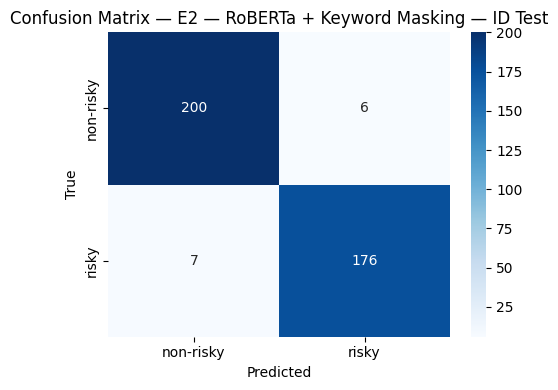

E2 — RoBERTa + Keyword Masking — OOD Test
Accuracy  : 0.6533
Precision : 0.7159
Recall    : 0.6696
Macro-F1  : 0.6389
Average confidence    : 0.9854
Confident wrong count : 51

Classification Report:


,precision,recall,f1-score,support
non-risky,0.850000,0.425000,0.566667,80.000000
risky,0.581818,0.914286,0.711111,70.000000
accuracy,0.653333,0.653333,0.653333,0.653333
macro avg,0.715909,0.669643,0.638889,150.000000
weighted avg,0.724848,0.653333,0.634074,150.000000


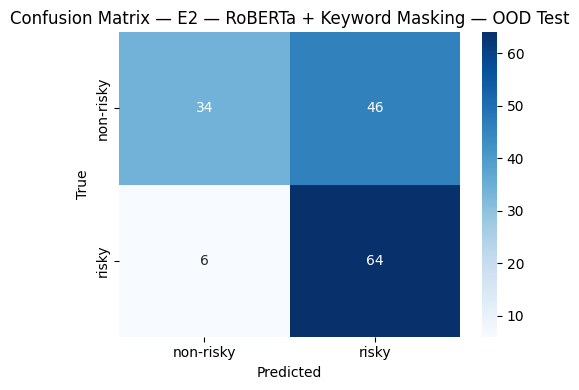


SHAP

SHAP ANALYSIS — E2: RoBERTa + Keyword Masking


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: risky
Non-risky probability: 0.0011
Risky probability    : 0.9989

SHAP waterfall explanation for risky class:


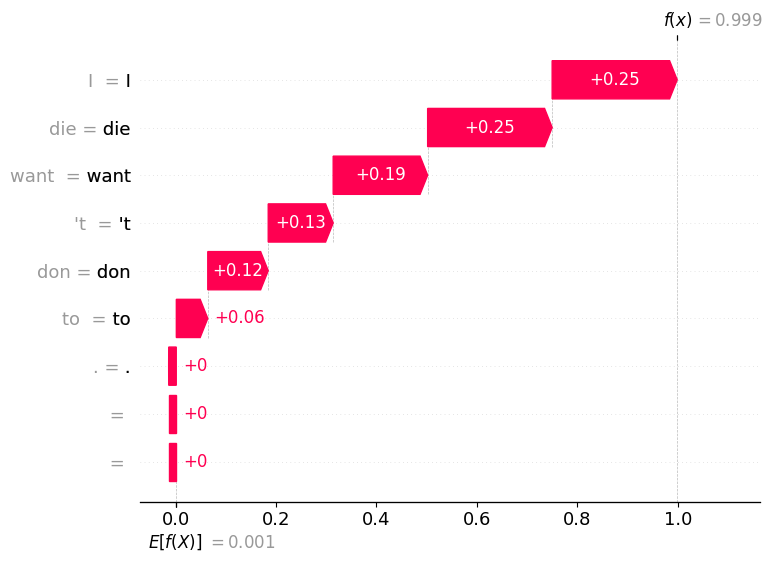


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: risky
Non-risky probability: 0.0009
Risky probability    : 0.9991

SHAP waterfall explanation for risky class:


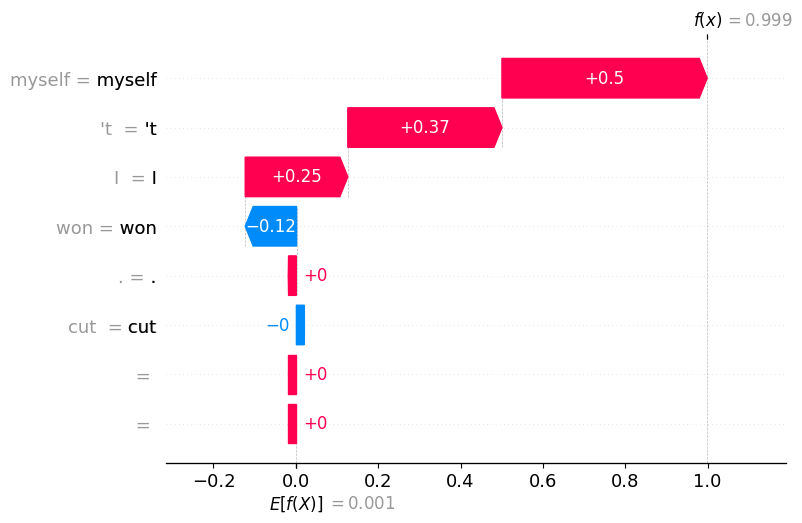


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: risky
Non-risky probability: 0.0036
Risky probability    : 0.9964

SHAP waterfall explanation for risky class:


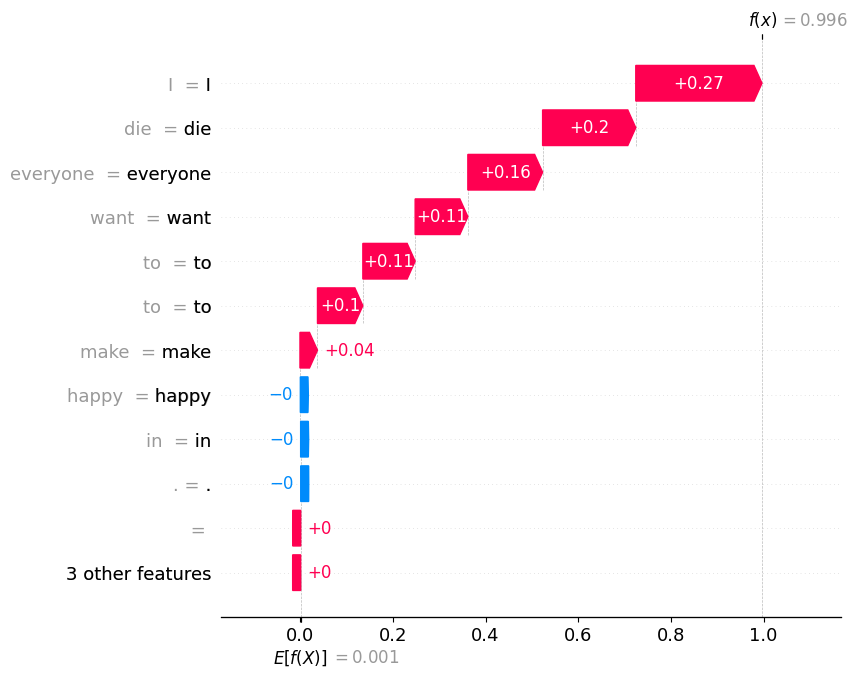

In [40]:
run_one_experiment("E2", run_training=True, run_evaluation=True, run_shap=True)

In [41]:
run_one_experiment("E3", run_training=True, run_evaluation=True, run_shap=True)


####################################################################################################
E3: RoBERTa + Counterfactual Augmentation
####################################################################################################

TRAINING
python -m src.train_roberta --experiment_id E3 --train_file data/processed/train_counterfactual.csv
Loading dataset from: data/processed/train_counterfactual.csv
Loaded 2112 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/val.csv
Loaded 388 rows.

Training configuration:
Experiment ID: E3
Model family: roberta
Model name: roberta-base
Train file: data/processed/train_counterfactual.csv
Validation file: /home/ubuntu/shortcut-learning-risky-intent/data/processed/val.csv
Replay file: None
Replay repeat: 0
Max length: 128
Batch size: 16
Epochs: 3
Learning rate: 2e-05
Seed: 42


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4588.32it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting fine-tuning...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2532', 'grad_norm': '0.2725', 'learning_rate': '1.85e-05', 'epoch': '1.894'}



Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.57s/it]
Traceback (most recent call last):
  File "/opt/jupyter/venv/lib/python3.12/site-packages/torch/serialization.py", line 1004, in save
    _save(
  File "/opt/jupyter/venv/lib/python3.12/site-packages/torch/serialization.py", line 1313, in _save
    zip_file.write_record(name, storage, num_bytes)
RuntimeError: basic_ios::clear: iostream error

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/ubuntu/shortcut-learning-risky-intent/src/train_roberta.py", line 45, in <module>
    main()
  File "/home/ubuntu/shortcut-learning-risky-intent/src/train_roberta.py", line 35, in main
    train_transformer(
  File "/home/ubuntu/shortcut-learning-risky-intent/src/train_transformer.py", line 295, in train_transformer
    trainer.train()
  File "/opt/jupyter/venv

RuntimeError: Command failed:
python -m src.train_roberta --experiment_id E3 --train_file data/processed/train_counterfactual.csv

In [ ]:
run_one_experiment("E4", run_training=True, run_evaluation=True, run_shap=True)

In [ ]:
run_one_experiment("E5", run_training=True, run_evaluation=True, run_shap=True)

In [ ]:
run_one_experiment("E6", run_training=False, run_evaluation=True, run_shap=True)

In [ ]:
run_one_experiment("E7", run_training=True, run_evaluation=True, run_shap=True)

In [ ]:
run_one_experiment("E8", run_training=True, run_evaluation=True, run_shap=True)

In [ ]:
run_one_experiment("E9", run_training=True, run_evaluation=True, run_shap=True)

In [ ]:
run_one_experiment("E10", run_training=True, run_evaluation=True, run_shap=True)